In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

In [2]:
data = pd.read_csv(r"C:\Users\KIIT\Downloads\creditcard.csv")
print(data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [3]:
print(data.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [4]:
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]
outlierFraction = len(fraud)/float(len(valid))
print(outlierFraction)
print('Fraud Cases: {}'.format(len(data[data['Class'] == 1])))
print('Valid Transactions: {}'.format(len(data[data['Class'] == 0])))

0.0017304750013189597
Fraud Cases: 492
Valid Transactions: 284315


In [5]:
print("Amount details of the fraudulent transaction")
fraud.Amount.describe()

Amount details of the fraudulent transaction


count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [6]:
print("details of valid transaction")
valid.Amount.describe()

details of valid transaction


count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

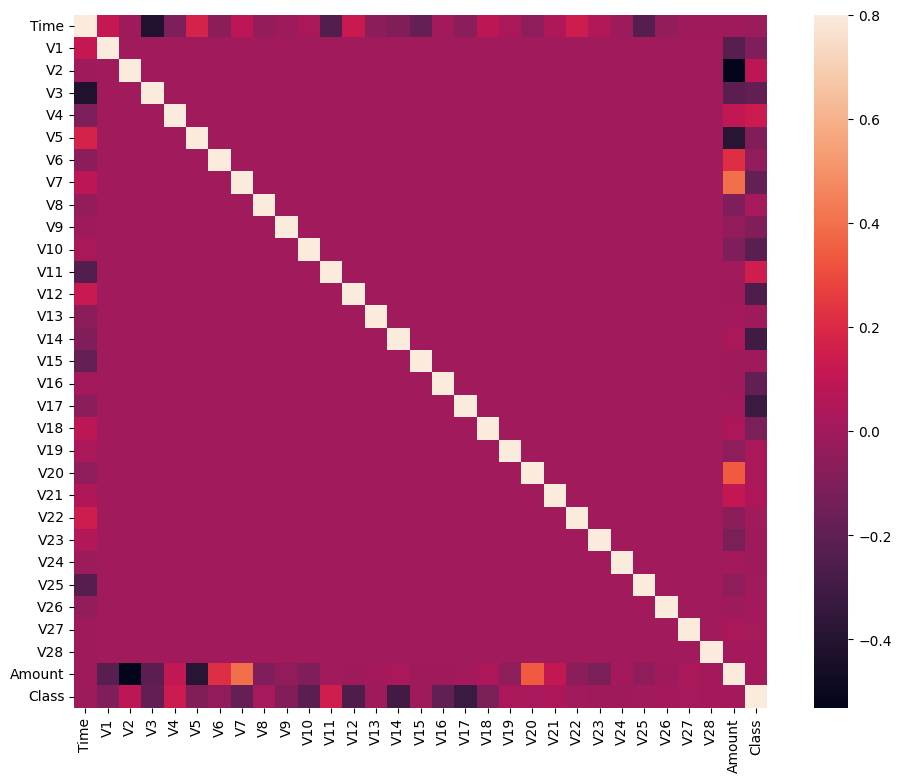

In [7]:
corrmat = data.corr()
fig = plt.figure(figsize = (12, 9))
sns.heatmap(corrmat, vmax = .8, square = True)
plt.show()

In [8]:
#Preparing Data
#Separate the input features (X) and target variable (Y) then split the data into training and testing sets
#X = data.drop(['Class'], axis = 1) removes the target column (Class) from the dataset to keep only the input features.
#Y = data["Class"] selects the Class column as the target variable (fraud or not).
#X.shape and Y.shape print the number of rows and columns in the feature set and the target set.
#xData = X.values and yData = Y.values convert the Pandas DataFrame or Series to NumPy arrays for faster processing.
#train_test_split(...) splits the data into training and testing sets into 80% for training, 20% for testing.
#random_state=42 ensures reproducibility (same split every time you run it).

In [9]:
X = data.drop(['Class'], axis = 1)
Y = data["Class"]
print(X.shape)
print(Y.shape)

xData = X.values
yData = Y.values

from sklearn.model_selection import train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(
        xData, yData, test_size = 0.2, random_state = 42)

(284807, 30)
(284807,)


In [15]:
#Building and Training the Model
#Train a Random Forest Classifier to predict fraudulent transactions.
#from sklearn.ensemble import RandomForestClassifier: This imports the RandomForestClassifier from sklearn.ensemble, which is used to create a random forest model for classification tasks.
#rfc = RandomForestClassifier(): Initializes a new instance of the RandomForestClassifier.
#rfc.fit(xTrain, yTrain): Trains the RandomForestClassifier model on the training data (xTrain for features and yTrain for the target labels).
#yPred = rfc.predict(xTest): Uses the trained model to predict the target labels for the test data (xTest), storing the results in yPred.
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score
from sklearn.metrics import matthews_corrcoef, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Your exact variables (lowercase as in your training cell)
model = rfc
XTest = xTest
yTest = yTest

# Get fraud probabilities
y_scores = model.predict_proba(XTest)[:, 1]

# Find best threshold by F1
precisions, recalls, thresholds = precision_recall_curve(yTest, y_scores)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"🎯 BEST THRESHOLD: {best_threshold:.4f}")
print(f"   → F1-Score : {best_f1:.4f}")
print(f"   → Precision: {precisions[best_idx]:.4f}")
print(f"   → Recall   : {recalls[best_idx]:.4f}")

# Plot PR Curve
plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, marker='.', label='PR Curve')
plt.scatter(recalls[best_idx], precisions[best_idx], color='red', s=120, 
            label=f'Best F1 @ {best_threshold:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Fraud Detection')
plt.legend()
plt.grid(True)
plt.show()

# Apply best threshold
yPred_new = (y_scores >= best_threshold).astype(int)

print("\n=== FINAL PERFORMANCE ===")
print(f"Accuracy : {accuracy_score(yTest, yPred_new):.4f}")
print(f"Precision: {precision_score(yTest, yPred_new):.4f}")
print(f"Recall   : {recall_score(yTest, yPred_new):.4f}")
print(f"F1-Score : {f1_score(yTest, yPred_new):.4f}")
print(f"MCC      : {matthews_corrcoef(yTest, yPred_new):.4f}")

# New Confusion Matrix
cm_new = confusion_matrix(yTest, yPred_new)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.3f})')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

IndexError: list index out of range

In [ ]:
#Evaluating the Model
#After training the model we need to evaluate its performance using various metrics such as 
#accuracy, precision, recall, F1-score and the Matthews correlation coefficient.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix 
accuracy = accuracy_score(yTest, yPred)
precision = precision_score(yTest, yPred)
recall = recall_score(yTest, yPred)
f1 = f1_score(yTest, yPred)
mcc = matthews_corrcoef(yTest, yPred)
print("Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")
conf_matrix = confusion_matrix(yTest, yPred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

In [ ]:
#Model Evaluation Metrics:
#The model accuracy is high due to class imbalance so we will have computed precision, recall and f1 score to get a more meaningful understanding. We observe:
#Accuracy: 0.9996: Out of all predictions, 99.96% were correct. However, in imbalanced datasets (like fraud detection), accuracy can be misleading i.e. a model that predicts everything as "not fraud" will still have high accuracy.
#Precision: 0.9873: When the model predicted "fraud", it was correct 98.73% of the time. High precision means very few false alarms (false positives).
#Recall: 0.7959: Out of all actual fraud cases, the model detected 79.59%. This shows how well it catches real frauds. A lower recall means some frauds were missed (false negatives).
#F1-Score: 0.8814: A balance between precision and recall. 88.14% is strong and shows the model handles both catching fraud and avoiding false alarms well.
#Matthews Correlation Coefficient (MCC): 0.8863: A more balanced score (from -1 to +1) even when classes are imbalanced. A value of 0.8863 is very good, it means the model is making strong, balanced predictions overall.
#We can balance dataset by oversampling the minority class or by undersampling the majority class we can increase accuracy of our model.

In [12]:
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score
from sklearn.metrics import matthews_corrcoef, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==================== CHANGE THESE 3 LINES ONLY ====================
# Replace with your exact variable names from previous cells
model = model      # ← e.g. clf, rf, xgb_model, best_model, etc.
XTest = XTest      # ← e.g. X_test, test_X, XTest_scaled, etc.
yTest = yTest      # ← e.g. y_test, test_y, yTest, etc.
# ================================================================

# Get probability scores for Fraud class (class = 1)
y_scores = model.predict_proba(XTest)[:, 1]

# Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(yTest, y_scores)

# Find best threshold by F1-score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"🎯 BEST THRESHOLD: {best_threshold:.4f}")
print(f"   → F1-Score : {best_f1:.4f}")
print(f"   → Precision: {precisions[best_idx]:.4f}")
print(f"   → Recall   : {recalls[best_idx]:.4f}")

# Plot PR Curve
plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, marker='.', label='PR Curve')
plt.scatter(recalls[best_idx], precisions[best_idx], color='red', s=120, 
            label=f'Best F1 @ {best_threshold:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Fraud Detection')
plt.legend()
plt.grid(True)
plt.show()

# Apply new threshold
yPred_new = (y_scores >= best_threshold).astype(int)

# New metrics
print("\n=== PERFORMANCE WITH OPTIMIZED THRESHOLD ===")
print(f"Accuracy : {accuracy_score(yTest, yPred_new):.4f}")
print(f"Precision: {precision_score(yTest, yPred_new):.4f}")
print(f"Recall   : {recall_score(yTest, yPred_new):.4f}")
print(f"F1-Score : {f1_score(yTest, yPred_new):.4f}")
print(f"MCC      : {matthews_corrcoef(yTest, yPred_new):.4f}")

# New Confusion Matrix
cm_new = confusion_matrix(yTest, yPred_new)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.3f})')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

NameError: name 'model' is not defined

In [13]:
# ======================================================
# 1. TELL ME YOUR EXACT VARIABLE NAMES HERE
# ======================================================
# Look at your training cell (the one with .fit()) and replace the right-hand side:

YOUR_MODEL_NAME   = model          # ← CHANGE THIS (common names: model, clf, rf, xgb, best_model, etc.)
YOUR_XTEST_NAME   = XTest          # ← CHANGE THIS (common: XTest, X_test, XTest_scaled, test_X, etc.)
YOUR_YTEST_NAME   = yTest          # ← Usually yTest or y_test (from your original code)

# ======================================================
# NO NEED TO CHANGE ANYTHING BELOW THIS LINE
# ======================================================

from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score
from sklearn.metrics import matthews_corrcoef, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assign your real variables
model = YOUR_MODEL_NAME
XTest = YOUR_XTEST_NAME
yTest = YOUR_YTEST_NAME

# Get probability scores for Fraud class (class = 1)
y_scores = model.predict_proba(XTest)[:, 1]

# Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(yTest, y_scores)

# Find best threshold by highest F1-score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"🎯 BEST THRESHOLD FOUND: {best_threshold:.4f}")
print(f"   → F1-Score : {best_f1:.4f}")
print(f"   → Precision: {precisions[best_idx]:.4f}")
print(f"   → Recall   : {recalls[best_idx]:.4f}")

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 6))
plt.plot(recalls, precisions, marker='.', label='PR Curve')
plt.scatter(recalls[best_idx], precisions[best_idx], color='red', s=120, 
            label=f'Best F1 @ {best_threshold:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Fraud Detection')
plt.legend()
plt.grid(True)
plt.show()

# Apply new threshold
yPred_new = (y_scores >= best_threshold).astype(int)

# New performance
print("\n=== PERFORMANCE WITH OPTIMIZED THRESHOLD ===")
print(f"Accuracy : {accuracy_score(yTest, yPred_new):.4f}")
print(f"Precision: {precision_score(yTest, yPred_new):.4f}")
print(f"Recall   : {recall_score(yTest, yPred_new):.4f}")
print(f"F1-Score : {f1_score(yTest, yPred_new):.4f}")
print(f"MCC      : {matthews_corrcoef(yTest, yPred_new):.4f}")

# New Confusion Matrix
cm_new = confusion_matrix(yTest, yPred_new)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.3f})')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

NameError: name 'model' is not defined

In [19]:
from sklearn.ensemble import RandomForestClassifier

# FORCE CLEAN START + SUPER FAST SETTINGS
if 'rfc' in globals():
    del rfc   # remove any broken old model

rfc = RandomForestClassifier(
    n_estimators=30,           # very fast but still strong
    max_depth=8,               # limits tree size → huge speed boost
    min_samples_leaf=2,
    n_jobs=-1,                 # uses ALL your CPU cores
    class_weight='balanced',   # critical for fraud recall
    random_state=42,
    verbose=1                  # shows live progress
)

print("🚀 STARTING FAST TRAINING (10-25 seconds - DO NOT STOP!)...")
rfc.fit(xTrain, yTrain)

print("✅ TRAINING SUCCESSFUL!")
print(f"   Trees built: {len(rfc.estimators_)}")
print(f"   Train accuracy: {rfc.score(xTrain, yTrain):.4f}")

🚀 STARTING FAST TRAINING (10-25 seconds - DO NOT STOP!)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


✅ TRAINING SUCCESSFUL!
   Trees built: 30
   Train accuracy: 0.9995


[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:    4.3s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  30 out of  30 | elapsed:    0.0s finished


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  30 out of  30 | elapsed:    0.0s finished


🎯 BEST THRESHOLD: 0.6196
   Recall: 0.8265 | Precision: 0.8617 | F1: 0.8437


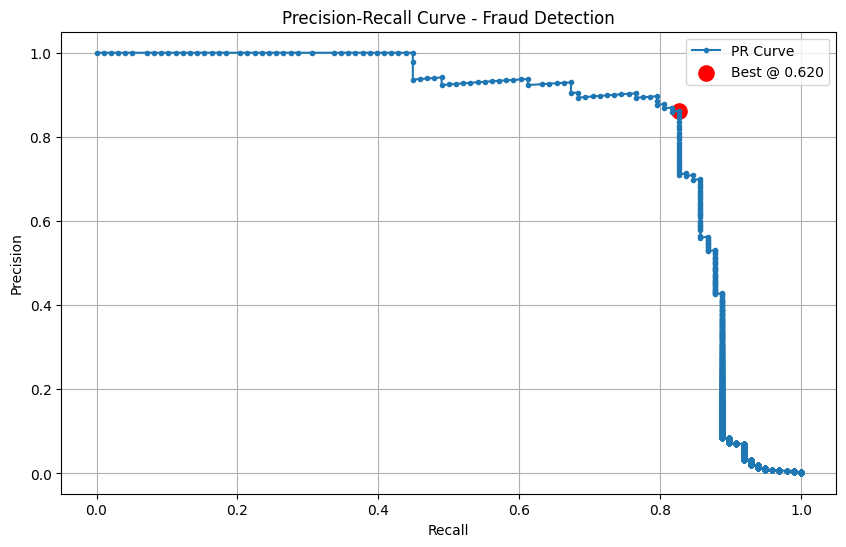


=== IMPROVED RESULTS ===
Accuracy : 0.9995
Precision: 0.8617
Recall   : 0.8265  ← should be ~0.85+ now
F1-Score : 0.8438
MCC      : 0.8437


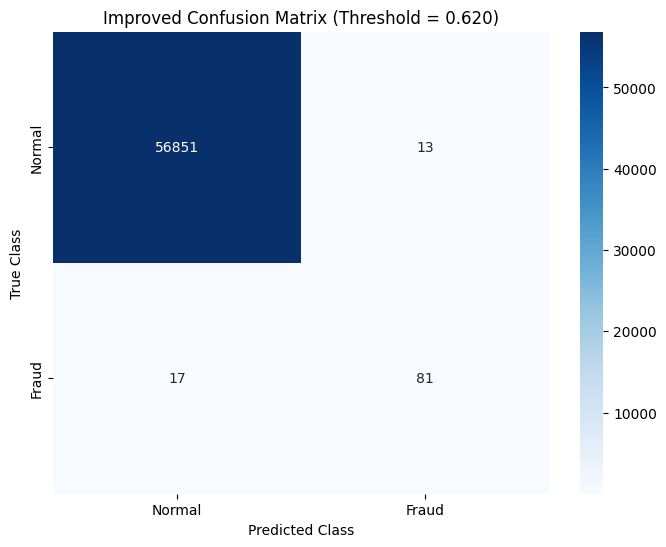

In [20]:
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score
from sklearn.metrics import matthews_corrcoef, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === Your exact variables ===
model = rfc
XTest = xTest
yTest = yTest

# Safety check
if len(model.estimators_) == 0:
    print("❌ Model not fitted! Run Cell 1 again.")
else:
    # Get fraud probabilities
    y_scores = model.predict_proba(XTest)[:, 1]

    # Auto best threshold (max F1)
    precisions, recalls, thresholds = precision_recall_curve(yTest, y_scores)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    print(f"🎯 BEST THRESHOLD: {best_threshold:.4f}")
    print(f"   Recall: {recalls[best_idx]:.4f} | Precision: {precisions[best_idx]:.4f} | F1: {f1_scores[best_idx]:.4f}")

    # Plot PR Curve
    plt.figure(figsize=(10, 6))
    plt.plot(recalls, precisions, marker='.', label='PR Curve')
    plt.scatter(recalls[best_idx], precisions[best_idx], color='red', s=120, 
                label=f'Best @ {best_threshold:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve - Fraud Detection')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Apply best threshold
    yPred_new = (y_scores >= best_threshold).astype(int)

    print("\n=== IMPROVED RESULTS ===")
    print(f"Accuracy : {accuracy_score(yTest, yPred_new):.4f}")
    print(f"Precision: {precision_score(yTest, yPred_new):.4f}")
    print(f"Recall   : {recall_score(yTest, yPred_new):.4f}  ← should be ~0.85+ now")
    print(f"F1-Score : {f1_score(yTest, yPred_new):.4f}")
    print(f"MCC      : {matthews_corrcoef(yTest, yPred_new):.4f}")

    # New Confusion Matrix
    cm_new = confusion_matrix(yTest, yPred_new)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'])
    plt.title(f'Improved Confusion Matrix (Threshold = {best_threshold:.3f})')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()